2025-01-03 22:24:49.179702: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-03 22:24:49.181565: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-03 22:24:49.184607: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-03 22:24:49.199919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1735910689.216398   27811 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1735910689.22

Train Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322730 entries, 0 to 322729
Data columns (total 45 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ts                      322730 non-null  int64  
 1   src_ip                  322730 non-null  object 
 2   src_port                322730 non-null  int64  
 3   dst_ip                  322730 non-null  object 
 4   dst_port                322730 non-null  int64  
 5   proto                   322730 non-null  object 
 6   service                 322730 non-null  object 
 7   duration                322730 non-null  float64
 8   src_bytes               322730 non-null  int64  
 9   dst_bytes               322730 non-null  int64  
 10  conn_state              322730 non-null  object 
 11  missed_bytes            322730 non-null  int64  
 12  src_pkts                322730 non-null  int64  
 13  src_ip_bytes            322730 non-null  int64  
 14  dst_p

/tmp/ipykernel_27811/432265042.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=data, palette='Set2')


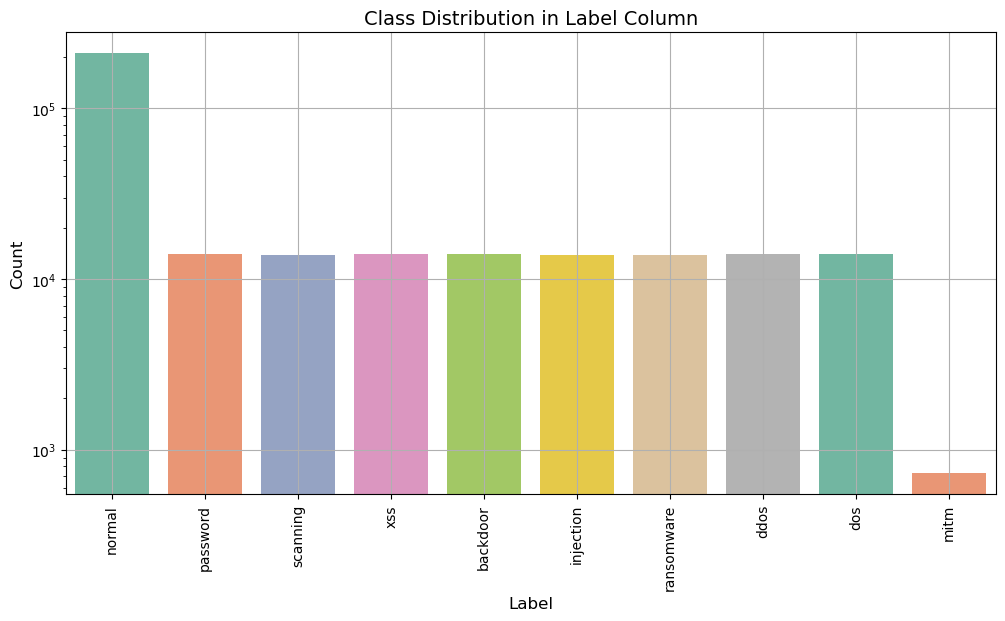

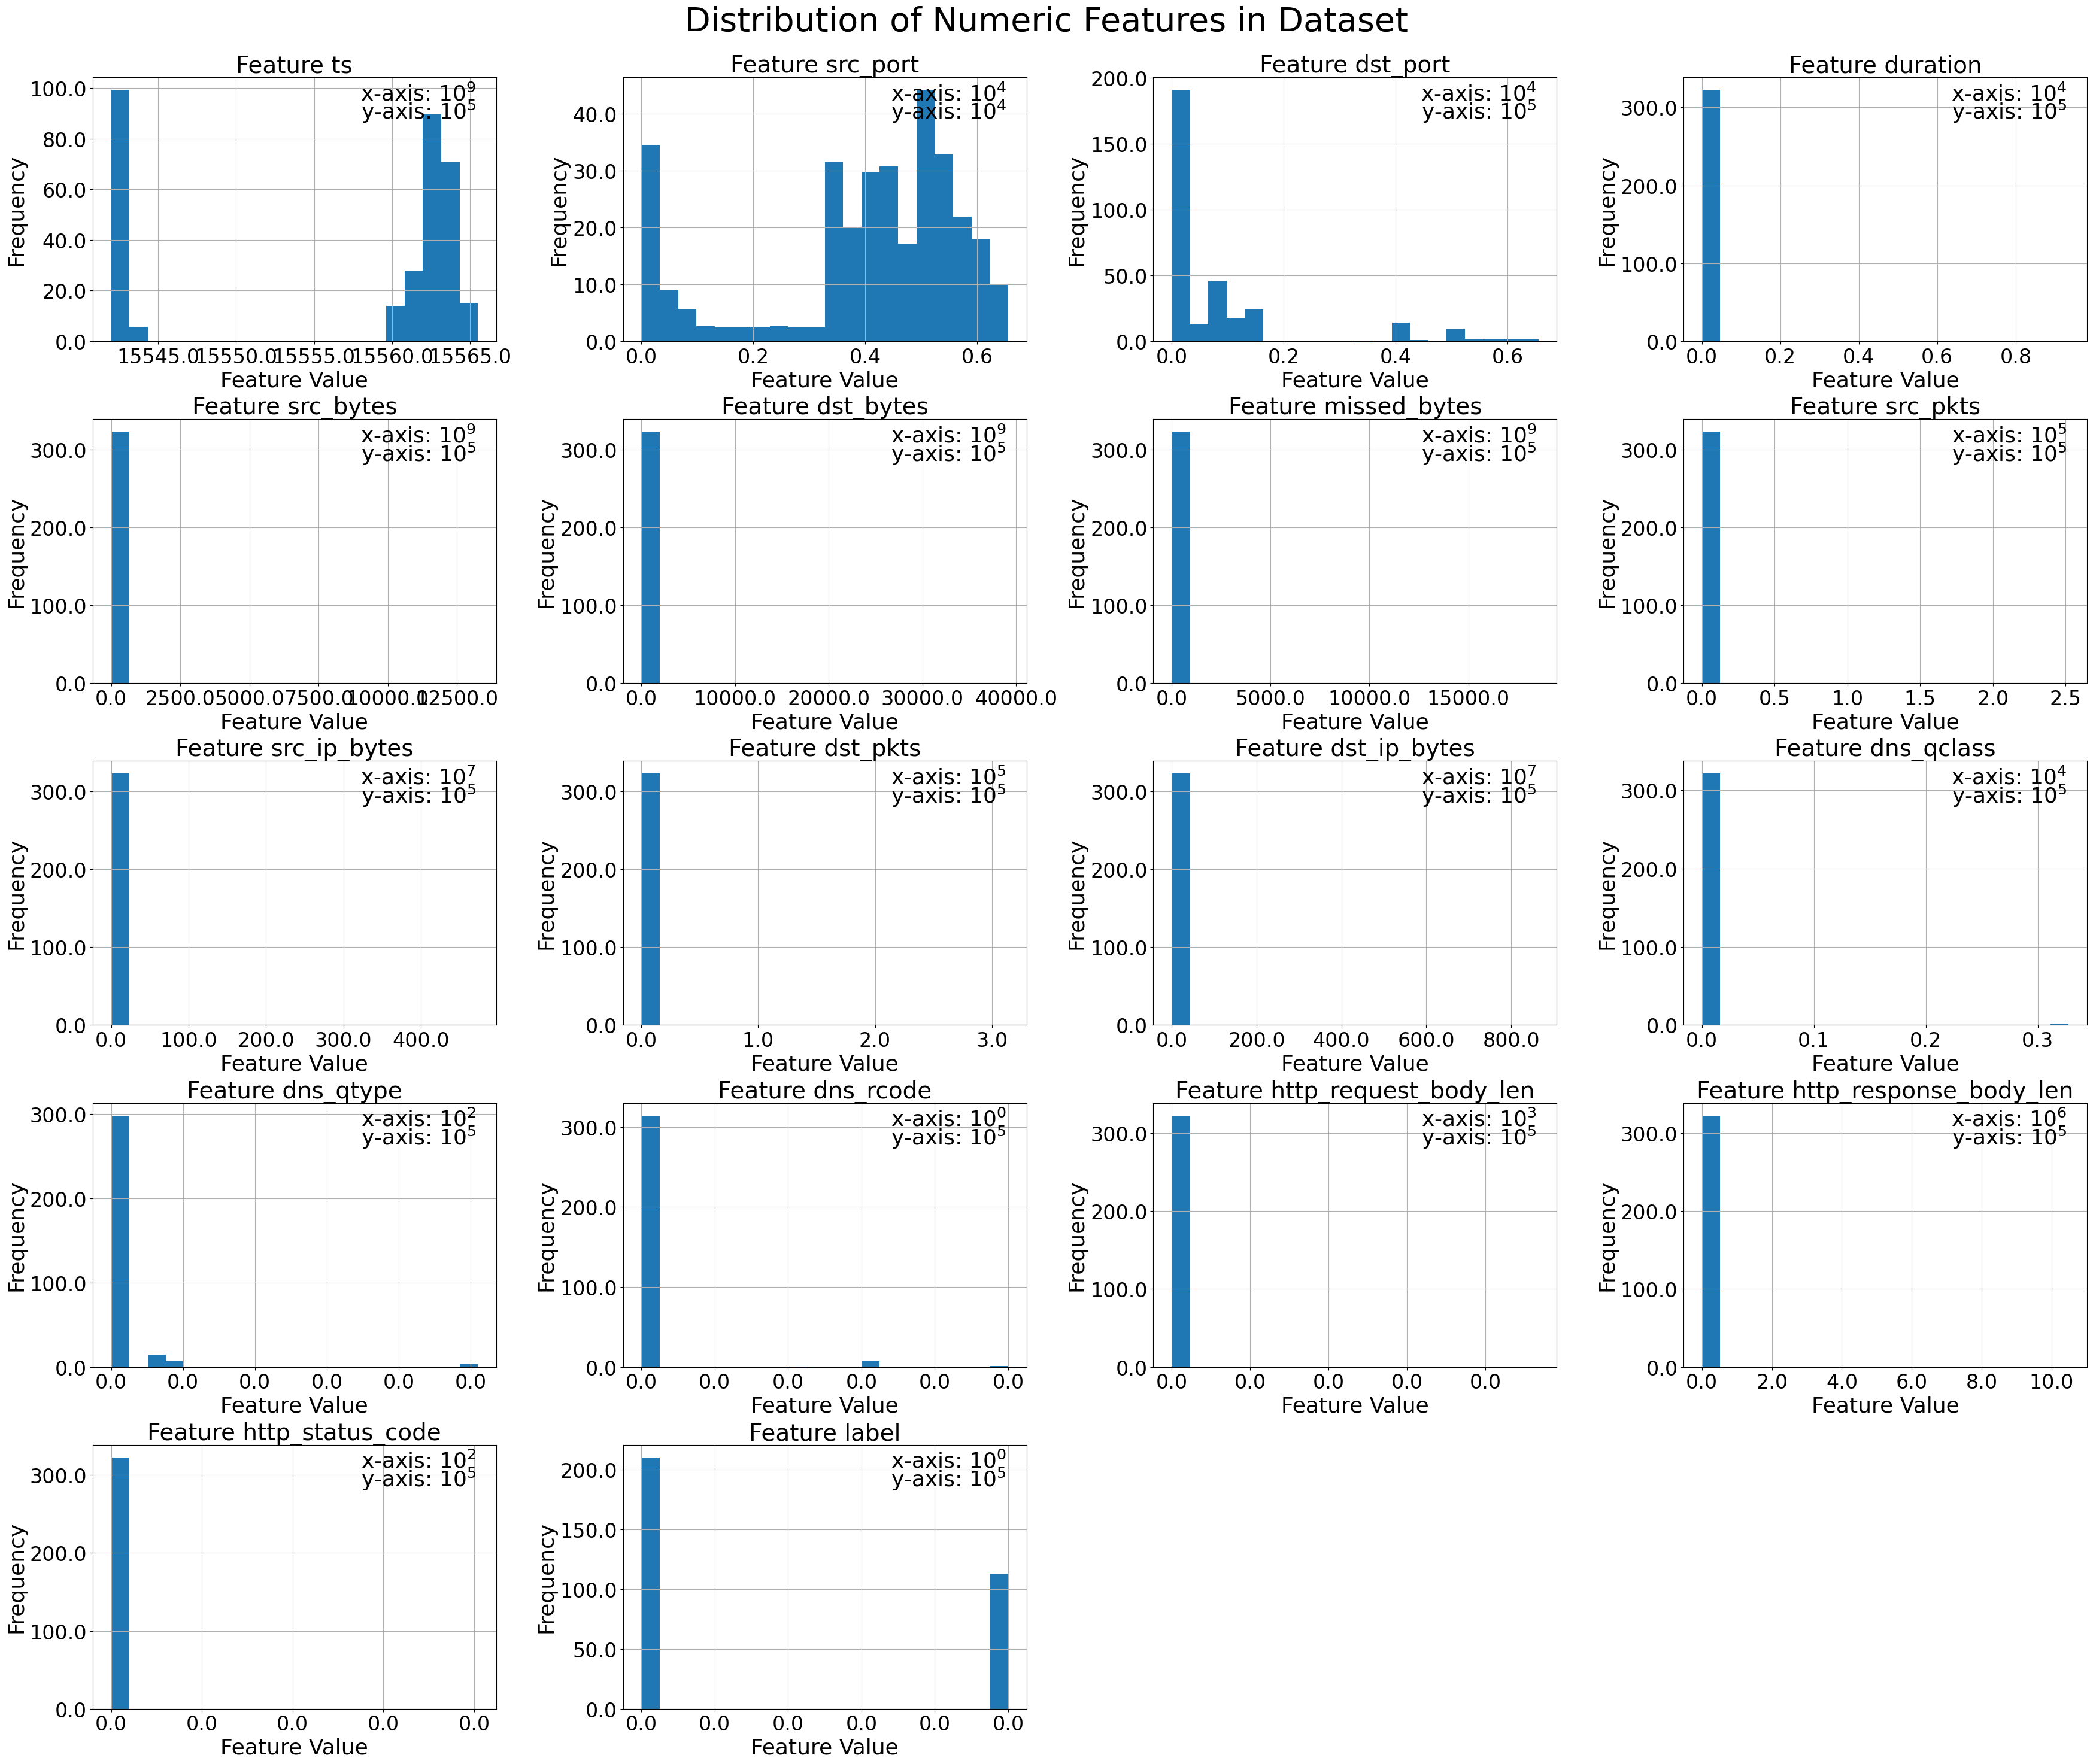

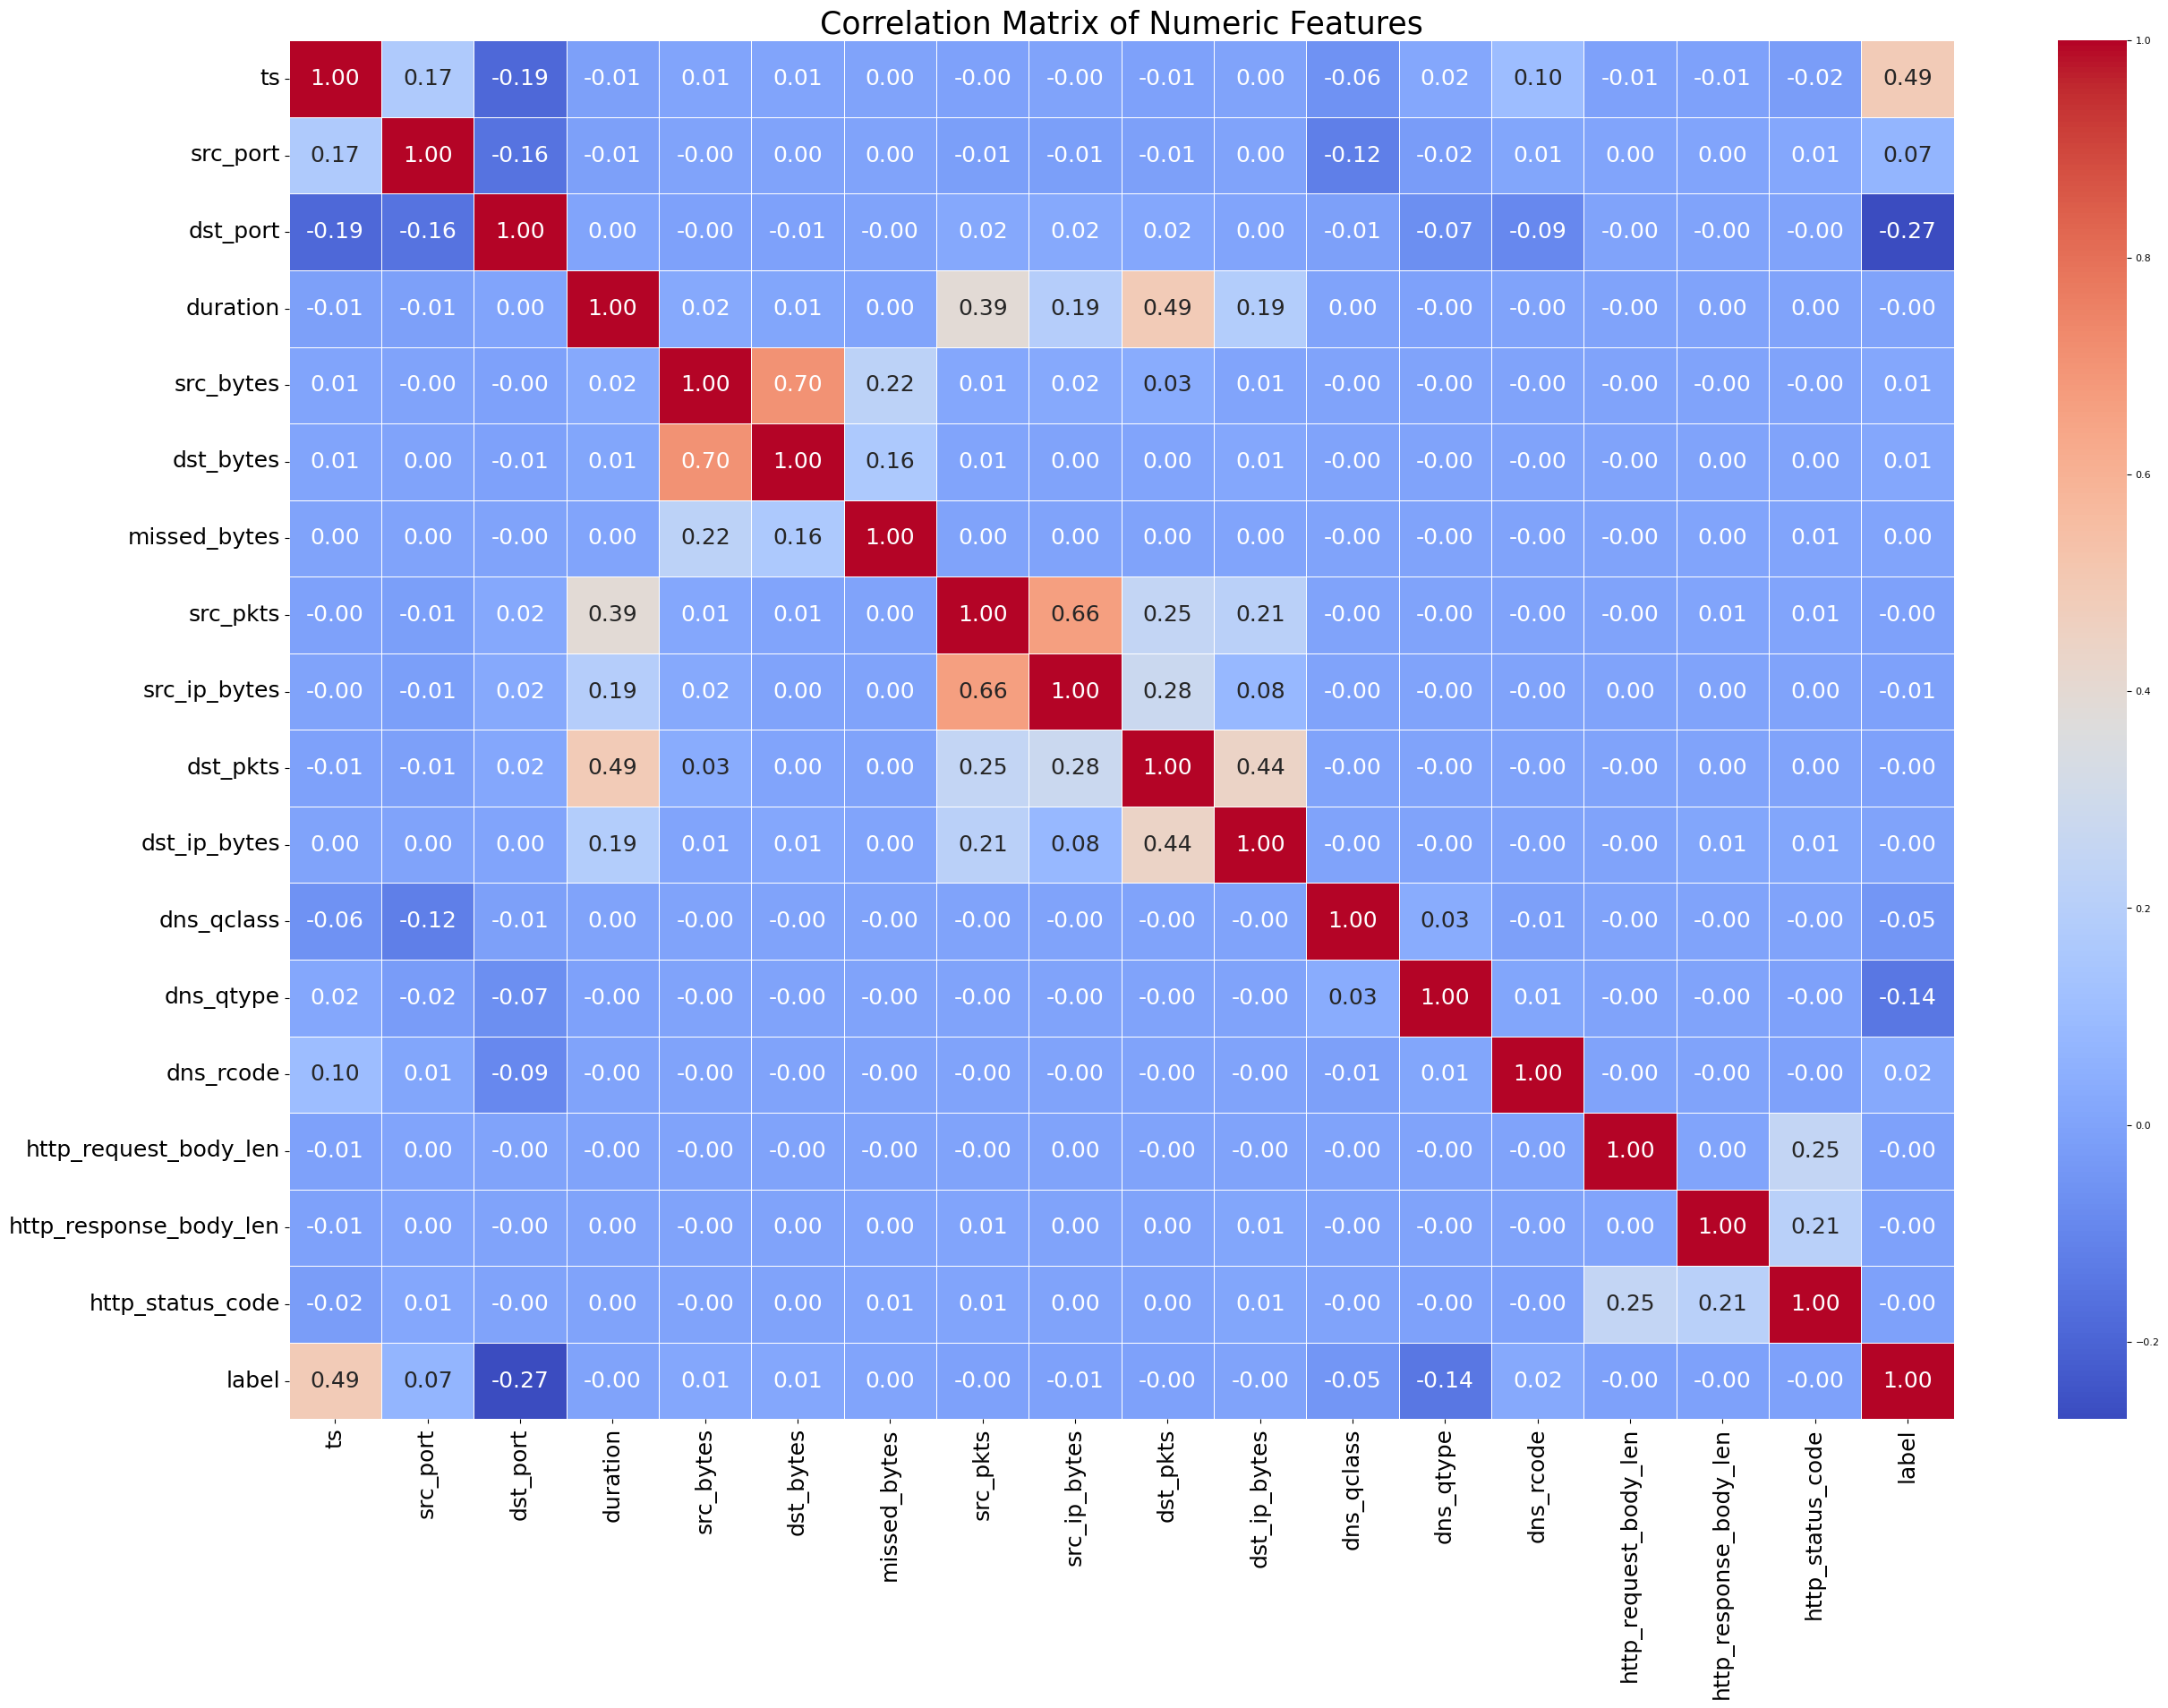

In [1]:
import import_ipynb
%run TON_IoT_data_preprocessing.ipynb


Validation Accuracy: 0.975476
Test Accuracy: 0.974956
RF_accuracy: 0.974956


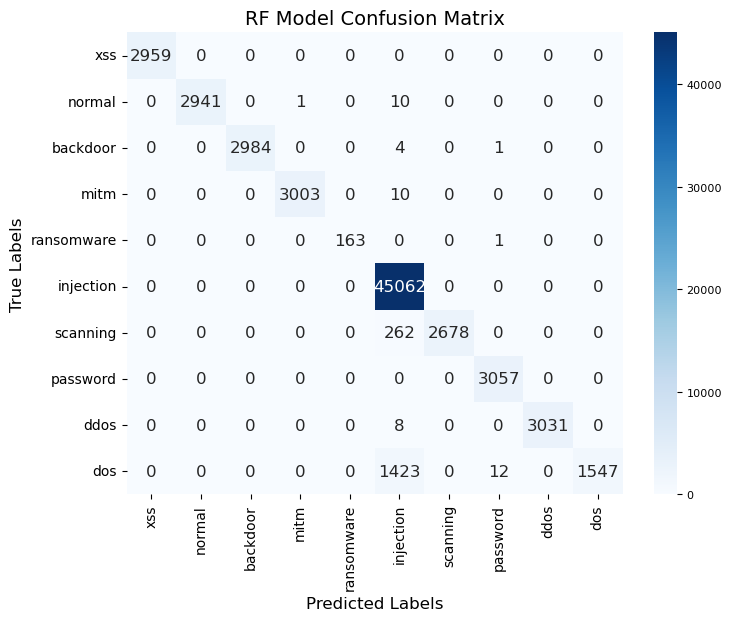

RF Model Classification Report:
              precision    recall  f1-score   support

         xss       1.00      1.00      1.00      2959
      normal       1.00      1.00      1.00      2952
    backdoor       1.00      1.00      1.00      2989
        mitm       1.00      1.00      1.00      3013
  ransomware       1.00      0.99      1.00       164
   injection       0.96      1.00      0.98     45062
    scanning       1.00      0.91      0.95      2940
    password       1.00      1.00      1.00      3057
        ddos       1.00      1.00      1.00      3039
         dos       1.00      0.52      0.68      2982

    accuracy                           0.97     69157
   macro avg       1.00      0.94      0.96     69157
weighted avg       0.98      0.97      0.97     69157



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_random_forest(X_train, y_train, X_val, y_val, X_test, y_test):
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = rf_model.predict(X_val)
    test_predictions = rf_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_random_forest(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"RF_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
plt.title("RF Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("RF Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


Validation Accuracy: 0.723148
Test Accuracy: 0.723181
MLP_accuracy: 0.723181


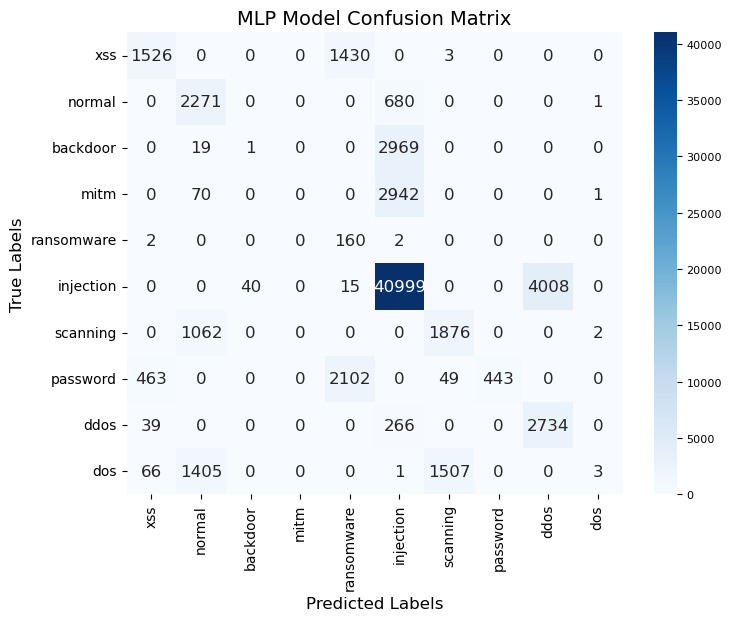

MLP Model Classification Report:
              precision    recall  f1-score   support

         xss       0.73      0.52      0.60      2959
      normal       0.47      0.77      0.58      2952
    backdoor       0.02      0.00      0.00      2989
        mitm       0.00      0.00      0.00      3013
  ransomware       0.04      0.98      0.08       164
   injection       0.86      0.91      0.88     45062
    scanning       0.55      0.64      0.59      2940
    password       1.00      0.14      0.25      3057
        ddos       0.41      0.90      0.56      3039
         dos       0.43      0.00      0.00      2982

    accuracy                           0.72     69157
   macro avg       0.45      0.49      0.36     69157
weighted avg       0.71      0.72      0.69     69157



/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_mlp(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize MLP model with one hidden layer of 100 units and a fixed random state
    mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
    mlp_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = mlp_model.predict(X_val)
    test_predictions = mlp_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_mlp(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"MLP_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
plt.title("MLP Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("MLP Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


Validation Accuracy: 0.941408
Test Accuracy: 0.941958
SVM_accuracy: 0.941958


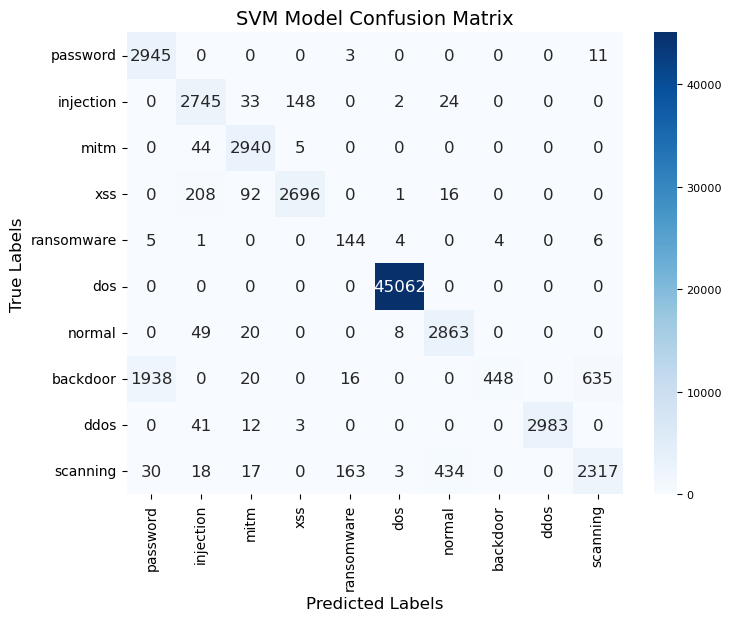

SVM Model Classification Report:
              precision    recall  f1-score   support

    password       0.60      1.00      0.75      2959
   injection       0.88      0.93      0.91      2952
        mitm       0.94      0.98      0.96      2989
         xss       0.95      0.89      0.92      3013
  ransomware       0.44      0.88      0.59       164
         dos       1.00      1.00      1.00     45062
      normal       0.86      0.97      0.91      2940
    backdoor       0.99      0.15      0.26      3057
        ddos       1.00      0.98      0.99      3039
    scanning       0.78      0.78      0.78      2982

    accuracy                           0.94     69157
   macro avg       0.84      0.86      0.81     69157
weighted avg       0.96      0.94      0.93     69157



In [2]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_svm(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize SVM model with a radial basis function kernel (RBF)
    svm_model = SVC(kernel='rbf', random_state=42)
    svm_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = svm_model.predict(X_val)
    test_predictions = svm_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_svm(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"SVM_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
plt.title("SVM Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("SVM Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


Validation Accuracy: 1.000000
Test Accuracy: 1.000000
Bagging_accuracy: 1.000000


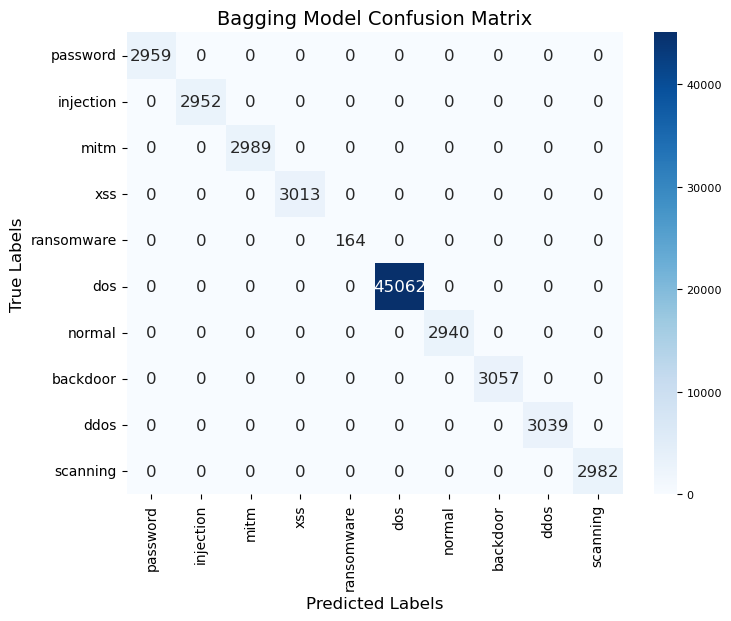

Bagging Model Classification Report:
              precision    recall  f1-score   support

    password       1.00      1.00      1.00      2959
   injection       1.00      1.00      1.00      2952
        mitm       1.00      1.00      1.00      2989
         xss       1.00      1.00      1.00      3013
  ransomware       1.00      1.00      1.00       164
         dos       1.00      1.00      1.00     45062
      normal       1.00      1.00      1.00      2940
    backdoor       1.00      1.00      1.00      3057
        ddos       1.00      1.00      1.00      3039
    scanning       1.00      1.00      1.00      2982

    accuracy                           1.00     69157
   macro avg       1.00      1.00      1.00     69157
weighted avg       1.00      1.00      1.00     69157



In [3]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

def train_bagging(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize BaggingClassifier with a DecisionTree as base estimator
    bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
    bagging_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = bagging_model.predict(X_val)
    test_predictions = bagging_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_bagging(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"Bagging_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
plt.title("Bagging Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("Bagging Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


Validation Accuracy: 0.708962
Test Accuracy: 0.708721
KNN_accuracy: 0.708721


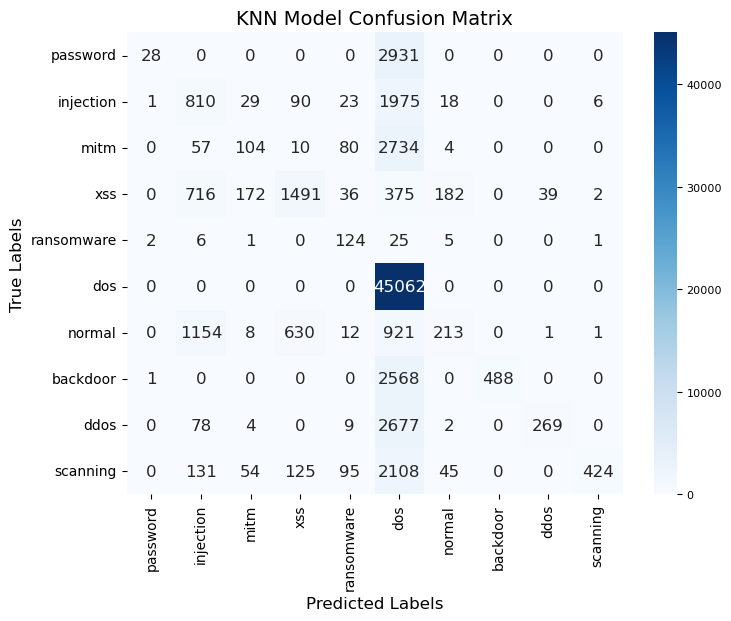

KNN Model Classification Report:
              precision    recall  f1-score   support

    password       0.88      0.01      0.02      2959
   injection       0.27      0.27      0.27      2952
        mitm       0.28      0.03      0.06      2989
         xss       0.64      0.49      0.56      3013
  ransomware       0.33      0.76      0.46       164
         dos       0.73      1.00      0.85     45062
      normal       0.45      0.07      0.12      2940
    backdoor       1.00      0.16      0.28      3057
        ddos       0.87      0.09      0.16      3039
    scanning       0.98      0.14      0.25      2982

    accuracy                           0.71     69157
   macro avg       0.64      0.30      0.30     69157
weighted avg       0.71      0.71      0.63     69157



In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_knn(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize KNN classifier with 5 neighbors
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = knn_model.predict(X_val)
    test_predictions = knn_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_knn(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"KNN_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
plt.title("KNN Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("KNN Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Validation Accuracy: 0.737478
Test Accuracy: 0.739260
AdaBoost_accuracy: 0.739260


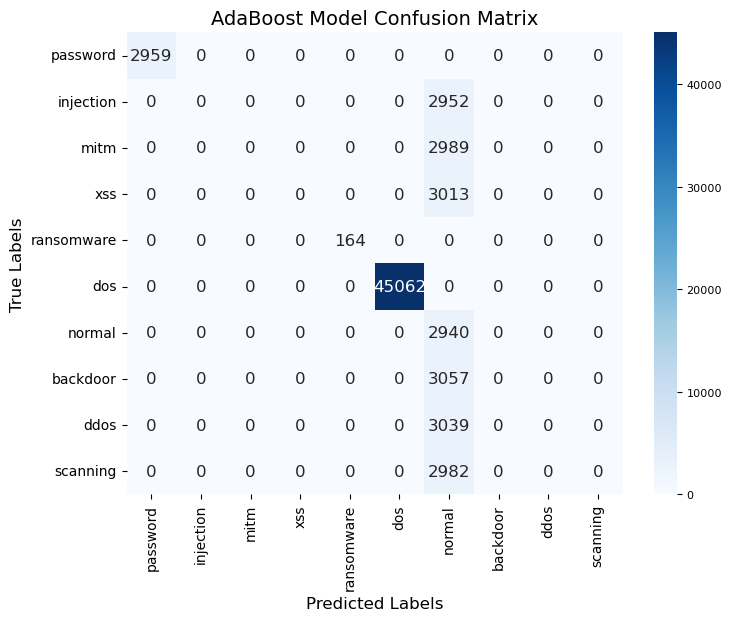

AdaBoost Model Classification Report:
              precision    recall  f1-score   support

    password       1.00      1.00      1.00      2959
   injection       0.00      0.00      0.00      2952
        mitm       0.00      0.00      0.00      2989
         xss       0.00      0.00      0.00      3013
  ransomware       1.00      1.00      1.00       164
         dos       1.00      1.00      1.00     45062
      normal       0.14      1.00      0.25      2940
    backdoor       0.00      0.00      0.00      3057
        ddos       0.00      0.00      0.00      3039
    scanning       0.00      0.00      0.00      2982

    accuracy                           0.74     69157
   macro avg       0.31      0.40      0.32     69157
weighted avg       0.70      0.74      0.71     69157



/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [5]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_adaboost(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize AdaBoostClassifier without explicitly defining base_estimator (default is DecisionTree)
    adaboost_model = AdaBoostClassifier(n_estimators=100, random_state=42)
    adaboost_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = adaboost_model.predict(X_val)
    test_predictions = adaboost_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_adaboost(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"AdaBoost_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
plt.title("AdaBoost Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("AdaBoost Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


Validation Accuracy: 1.000000
Test Accuracy: 1.000000
DecisionTree_accuracy: 1.000000


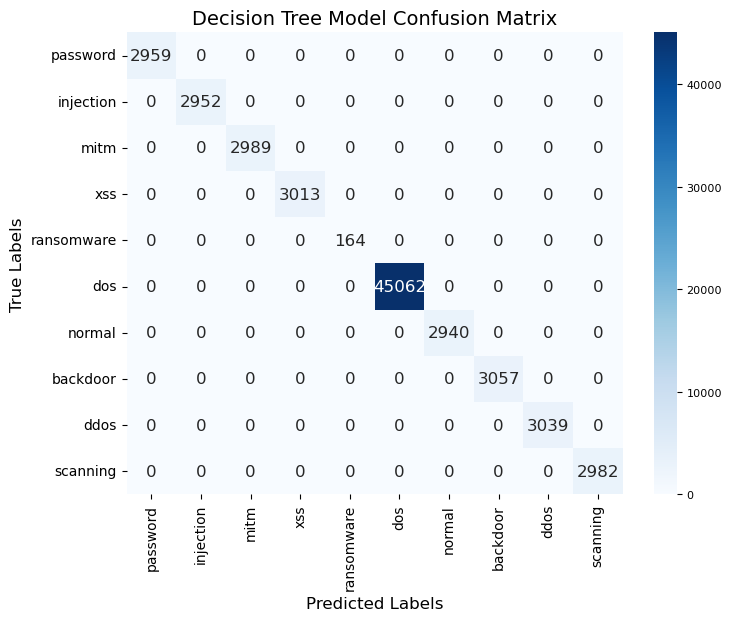

Decision Tree Model Classification Report:
              precision    recall  f1-score   support

    password       1.00      1.00      1.00      2959
   injection       1.00      1.00      1.00      2952
        mitm       1.00      1.00      1.00      2989
         xss       1.00      1.00      1.00      3013
  ransomware       1.00      1.00      1.00       164
         dos       1.00      1.00      1.00     45062
      normal       1.00      1.00      1.00      2940
    backdoor       1.00      1.00      1.00      3057
        ddos       1.00      1.00      1.00      3039
    scanning       1.00      1.00      1.00      2982

    accuracy                           1.00     69157
   macro avg       1.00      1.00      1.00     69157
weighted avg       1.00      1.00      1.00     69157



In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_decision_tree(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize DecisionTreeClassifier
    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = dt_model.predict(X_val)
    test_predictions = dt_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_decision_tree(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"DecisionTree_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
plt.title("Decision Tree Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("Decision Tree Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [23:16:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Validation Accuracy: 0.999060
Test Accuracy: 0.998988
XGBoost_accuracy: 0.998988


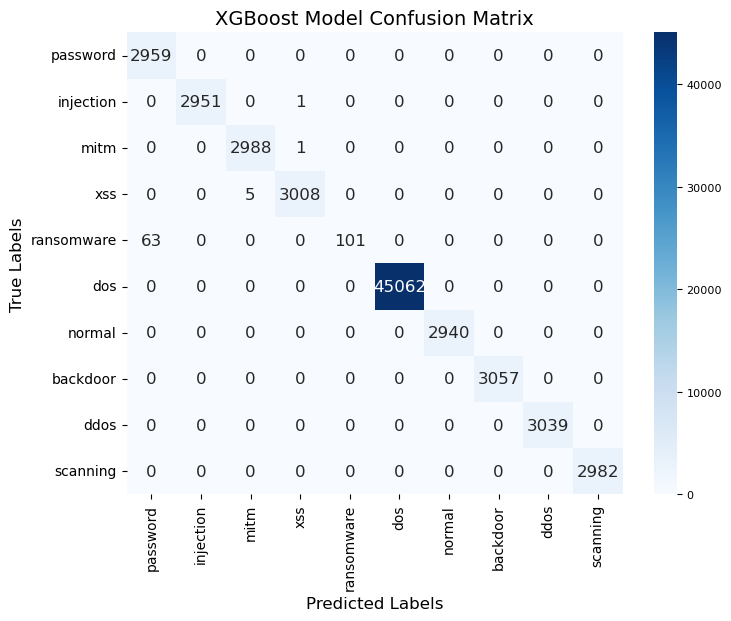

XGBoost Model Classification Report:
              precision    recall  f1-score   support

    password       0.98      1.00      0.99      2959
   injection       1.00      1.00      1.00      2952
        mitm       1.00      1.00      1.00      2989
         xss       1.00      1.00      1.00      3013
  ransomware       1.00      0.62      0.76       164
         dos       1.00      1.00      1.00     45062
      normal       1.00      1.00      1.00      2940
    backdoor       1.00      1.00      1.00      3057
        ddos       1.00      1.00      1.00      3039
    scanning       1.00      1.00      1.00      2982

    accuracy                           1.00     69157
   macro avg       1.00      0.96      0.97     69157
weighted avg       1.00      1.00      1.00     69157



In [7]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_xgboost(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize XGBClassifier
    xgboost_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
    xgboost_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = xgboost_model.predict(X_val)
    test_predictions = xgboost_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_xgboost(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"XGBoost_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
plt.title("XGBoost Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("XGBoost Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


0:	learn: 1.5046020	total: 171ms	remaining: 2m 50s
100:	learn: 0.0020836	total: 9.96s	remaining: 1m 28s
200:	learn: 0.0006703	total: 19.7s	remaining: 1m 18s
300:	learn: 0.0004111	total: 29.5s	remaining: 1m 8s
400:	learn: 0.0002970	total: 39.2s	remaining: 58.5s
500:	learn: 0.0002347	total: 49.3s	remaining: 49.1s
600:	learn: 0.0001960	total: 59.4s	remaining: 39.4s
700:	learn: 0.0001675	total: 1m 9s	remaining: 29.6s
800:	learn: 0.0001480	total: 1m 19s	remaining: 19.7s
900:	learn: 0.0001333	total: 1m 29s	remaining: 9.84s
999:	learn: 0.0001207	total: 1m 39s	remaining: 0us
Validation Accuracy: 0.957140
Test Accuracy: 0.956722
CatBoost_accuracy: 0.956722


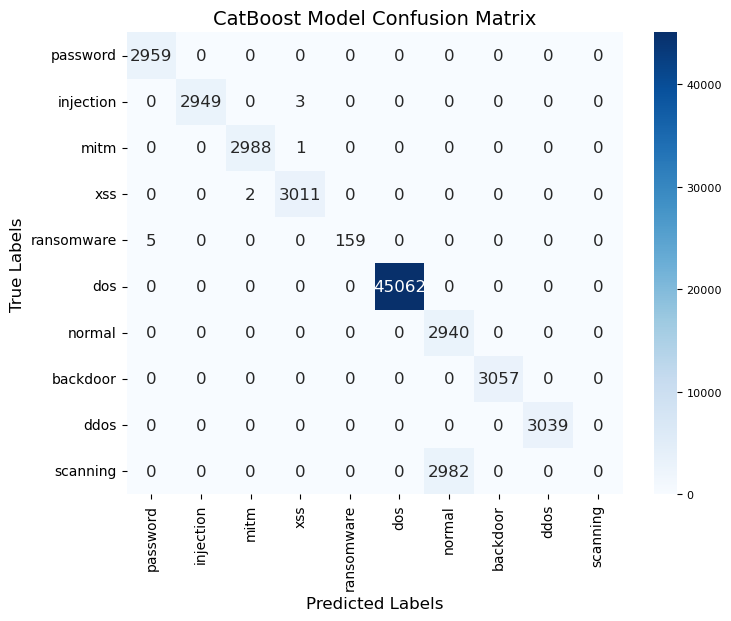

CatBoost Model Classification Report:
              precision    recall  f1-score   support

    password       1.00      1.00      1.00      2959
   injection       1.00      1.00      1.00      2952
        mitm       1.00      1.00      1.00      2989
         xss       1.00      1.00      1.00      3013
  ransomware       1.00      0.97      0.98       164
         dos       1.00      1.00      1.00     45062
      normal       0.50      1.00      0.66      2940
    backdoor       1.00      1.00      1.00      3057
        ddos       1.00      1.00      1.00      3039
    scanning       0.00      0.00      0.00      2982

    accuracy                           0.96     69157
   macro avg       0.85      0.90      0.86     69157
weighted avg       0.94      0.96      0.94     69157



/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [8]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_catboost(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize CatBoostClassifier
    catboost_model = CatBoostClassifier(random_state=42, iterations=1000, learning_rate=0.1, depth=6, cat_features=[])
    catboost_model.fit(X_train, y_train, cat_features=[], verbose=100)  # verbose=100 for progress info
    
    # Predict on validation and test sets
    val_predictions = catboost_model.predict(X_val)
    test_predictions = catboost_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_catboost(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"CatBoost_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
plt.title("CatBoost Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("CatBoost Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


Validation Accuracy: 0.694358
Test Accuracy: 0.697326
GNB_accuracy: 0.697326


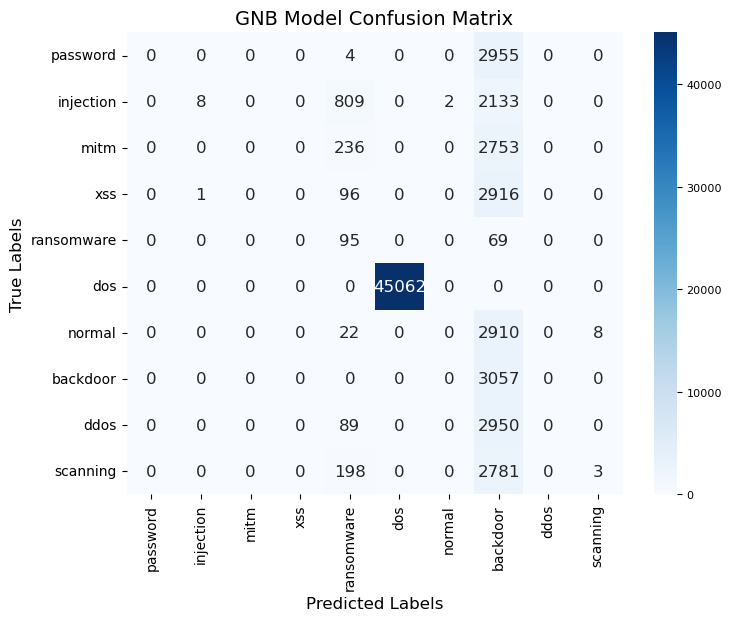

GNB Model Classification Report:
              precision    recall  f1-score   support

    password       0.00      0.00      0.00      2959
   injection       0.89      0.00      0.01      2952
        mitm       0.00      0.00      0.00      2989
         xss       0.00      0.00      0.00      3013
  ransomware       0.06      0.58      0.11       164
         dos       1.00      1.00      1.00     45062
      normal       0.00      0.00      0.00      2940
    backdoor       0.14      1.00      0.24      3057
        ddos       0.00      0.00      0.00      3039
    scanning       0.27      0.00      0.00      2982

    accuracy                           0.70     69157
   macro avg       0.24      0.26      0.14     69157
weighted avg       0.71      0.70      0.66     69157



/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [9]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_gnb(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize GNB classifier
    gnb_model = GaussianNB()
    gnb_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = gnb_model.predict(X_val)
    test_predictions = gnb_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_gnb(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"GNB_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
plt.title("GNB Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("GNB Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


Validation Accuracy: 0.748626
Test Accuracy: 0.749338
LR_accuracy: 0.749338


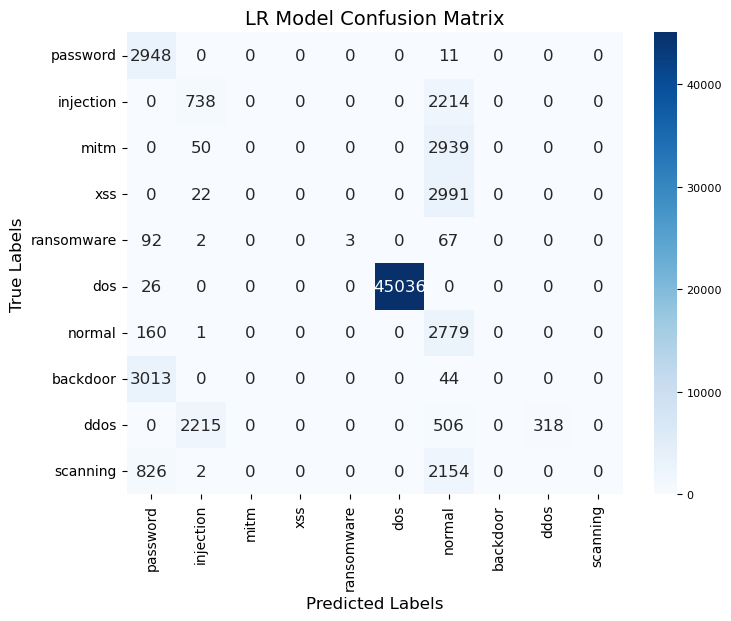

LR Model Classification Report:
              precision    recall  f1-score   support

    password       0.42      1.00      0.59      2959
   injection       0.24      0.25      0.25      2952
        mitm       0.00      0.00      0.00      2989
         xss       0.00      0.00      0.00      3013
  ransomware       1.00      0.02      0.04       164
         dos       1.00      1.00      1.00     45062
      normal       0.20      0.95      0.33      2940
    backdoor       0.00      0.00      0.00      3057
        ddos       1.00      0.10      0.19      3039
    scanning       0.00      0.00      0.00      2982

    accuracy                           0.75     69157
   macro avg       0.39      0.33      0.24     69157
weighted avg       0.73      0.75      0.71     69157



/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_lr(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize Logistic Regression model
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = lr_model.predict(X_val)
    test_predictions = lr_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_lr(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"LR_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
plt.title("LR Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("LR Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))


Validation Accuracy: 0.818700
Test Accuracy: 0.818182
RidgeClassifier_accuracy: 0.818182


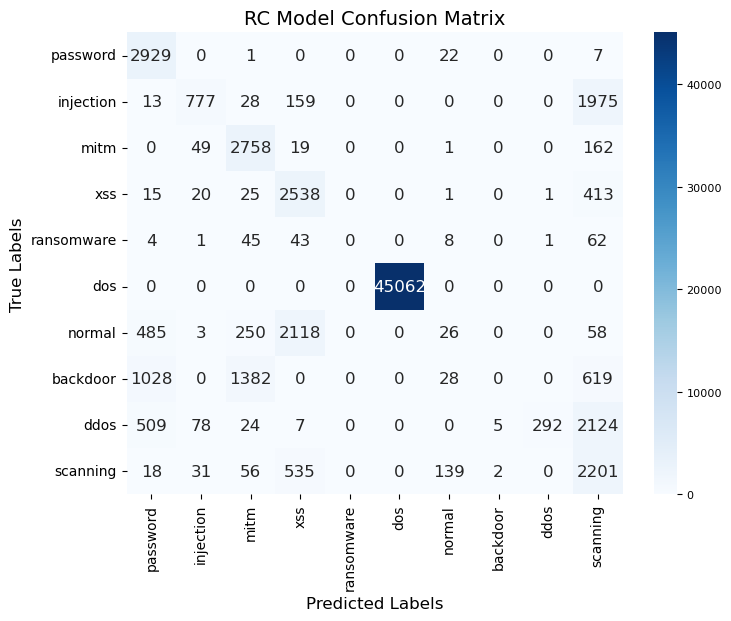

RC Model Classification Report:
              precision    recall  f1-score   support

    password       0.59      0.99      0.74      2959
   injection       0.81      0.26      0.40      2952
        mitm       0.60      0.92      0.73      2989
         xss       0.47      0.84      0.60      3013
  ransomware       0.00      0.00      0.00       164
         dos       1.00      1.00      1.00     45062
      normal       0.12      0.01      0.02      2940
    backdoor       0.00      0.00      0.00      3057
        ddos       0.99      0.10      0.18      3039
    scanning       0.29      0.74      0.42      2982

    accuracy                           0.82     69157
   macro avg       0.49      0.49      0.41     69157
weighted avg       0.82      0.82      0.78     69157



/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/monetai2/anaconda3/envs/alvy/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [11]:
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_ridge(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize Ridge Classifier
    ridge_model = RidgeClassifier(random_state=42)
    ridge_model.fit(X_train, y_train)
    
    # Predict on validation and test sets
    val_predictions = ridge_model.predict(X_val)
    test_predictions = ridge_model.predict(X_test)
    
    # Calculate and print accuracy
    val_accuracy = accuracy_score(y_val, val_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Validation Accuracy: {val_accuracy:.6f}")
    print(f"Test Accuracy: {test_accuracy:.6f}")
    
    return test_accuracy, y_test, test_predictions

# Train the model and get predictions
meta_accuracy, y_meta_test, meta_predictions = train_ridge(X_train, y_train, X_val, y_val, X_test, y_test)

# Print test accuracy
print(f"RidgeClassifier_accuracy: {meta_accuracy:.6f}")

# Confusion matrix
cm_meta = confusion_matrix(y_meta_test, meta_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_meta, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
plt.title("RC Model Confusion Matrix", fontsize=14)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)  
plt.show()

# Classification report
print("RC Model Classification Report:")
print(classification_report(y_meta_test, meta_predictions, target_names=labels))
